# **MULTICOLLINEARITY TREATMENT PROJECT**
- Multicollinearity is when there are independent features that are highly correlated to one another, causing for bad model performance

# Imports

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error
from numpy.linalg import eig

# Create Dataset

In [16]:
np.random.seed(73)

In [47]:
# Create Features
num_players = 200
batting_average = np.random.normal(0.28, 0.05, num_players)
batting_average = np.clip(batting_average, 0.2, 0.4)
AB = np.random.randint(300, 700, num_players)
H = AB * batting_average
Height = np.random.normal(72, 6, num_players)
Wind = np.random.uniform(-1.5, 1.5, num_players)
RBIs = (H * 0.5) + (AB * 0.02) + (Height * 0.01) + (Wind * 7) + np.random.normal(0, 10, num_players)

RBIs_rounded = np.round(RBIs)
H_rounded = np.round(H)
AB_rounded = np.round(AB)

In [48]:
data = pd.DataFrame({
    'AB': AB_rounded,
    'H': H_rounded,
    'Height': Height,
    'Wind': Wind,
    'RBIs': RBIs_rounded
})

In [51]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
AB,200.0,484.750000,120.989503,301.000000,369.750000,470.000000,587.500000,699.000000
H,200.0,132.695000,38.678055,62.000000,102.750000,128.000000,158.250000,225.000000
Height,200.0,72.213234,5.997954,55.634895,68.135387,71.938507,75.951122,88.946972
Wind,200.0,0.014607,0.886877,-1.492182,-0.779722,-0.031485,0.756939,1.492776
RBIs,200.0,76.800000,24.095288,11.000000,59.000000,76.000000,93.000000,140.000000


In [52]:
data.head()

,AB,H,Height,Wind,RBIs
0,464,95.0,87.800572,1.241585,70.0
1,518,191.0,70.031047,-1.190100,99.0
2,327,75.0,61.055854,-0.254949,29.0
3,352,79.0,67.997375,-1.199911,49.0
4,353,100.0,78.625986,0.755702,90.0


# Train Test Split

In [53]:
X = data[['AB', 'H', 'Height', 'Wind']]
y = data['RBIs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
X.head()

,AB,H,Height,Wind
0,464,95.0,87.800572,1.241585
1,518,191.0,70.031047,-1.190100
2,327,75.0,61.055854,-0.254949
3,352,79.0,67.997375,-1.199911
4,353,100.0,78.625986,0.755702


In [55]:
X_train.head()

,AB,H,Height,Wind
79,507,147.0,75.979689,-0.496605
197,455,99.0,82.896877,-0.280905
38,369,124.0,72.286617,0.899384
24,567,113.0,60.872831,0.006551
122,382,96.0,70.794279,-0.490611


# Baseline Linear Regression Model predicting RBIs (prior to multicollinearity treatment)

In [79]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# Print the MSE, RMSE, R2 Score, and MAE of the Baseline Model
print(f'Mean                                   : {y_pred.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred))/(y_pred.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred)}')

Mean                                   : 73.80596188819412
Mean Squared Error                     : 73.94824562410572
Root Mean Squared Error                : 8.599316578897751
Root Mean Squared Error as a % of Mean : 0.11651249247214653
R2 Score                               : 0.8820301103565412
Mean Absolute Error                    : 6.998828484794293


Our RMSE Scores are pretty decent, but definitely could be better. Ideally, RMSE as a % of mean should be less than 10% to be considered a good model (currently 11%). Also, our R2 score is less than 90% which means there is room for improvement. We will try to identify any multicollinearity within our independent variables and treat them if any are found.

# Investigate Multicollinearity

### 1.) Correlation Matrix 

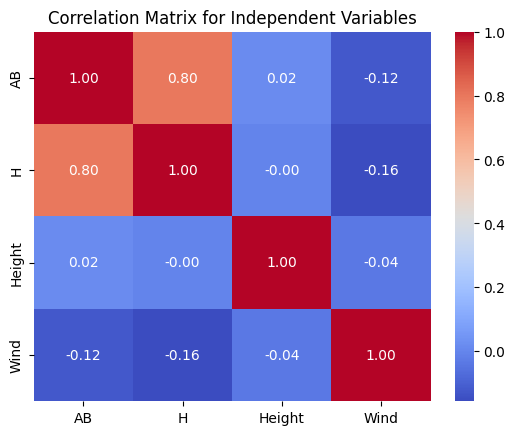

In [58]:
# Create a correlation matrix for the full independent variable (X) dataset
corr_matrix = X.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'Correlation Matrix for Independent Variables')
plt.show()

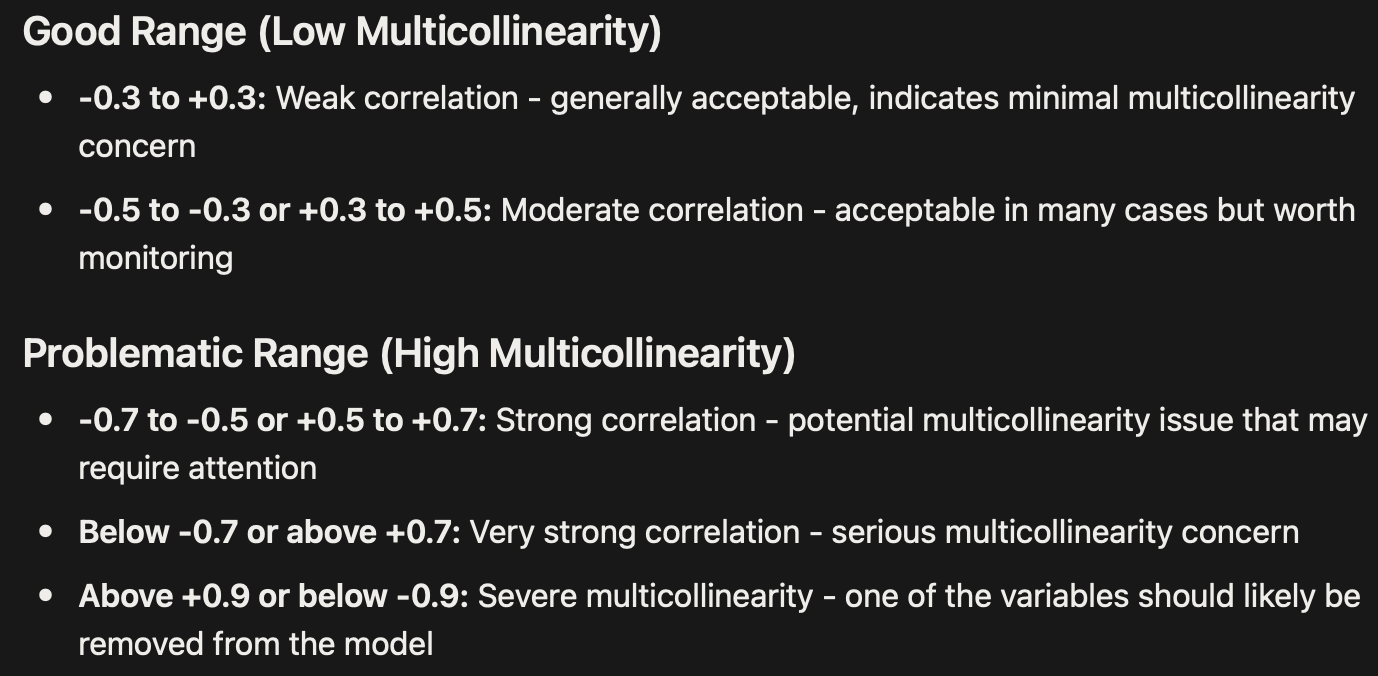

In the correlation matrix above, we can see that the Hits (H) and At-Bats (AB) variable are highly correlated to one another (0.80). This is a strong indicator of multicollinearity in our dataset. We will still check the Variance Inflation Factor and the Condition Index.

### 2.) Variance Inflation Factor

In [67]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Feature,VIF
0,AB,46.971332
1,H,35.968297
2,Height,15.896379
3,Wind,1.020282


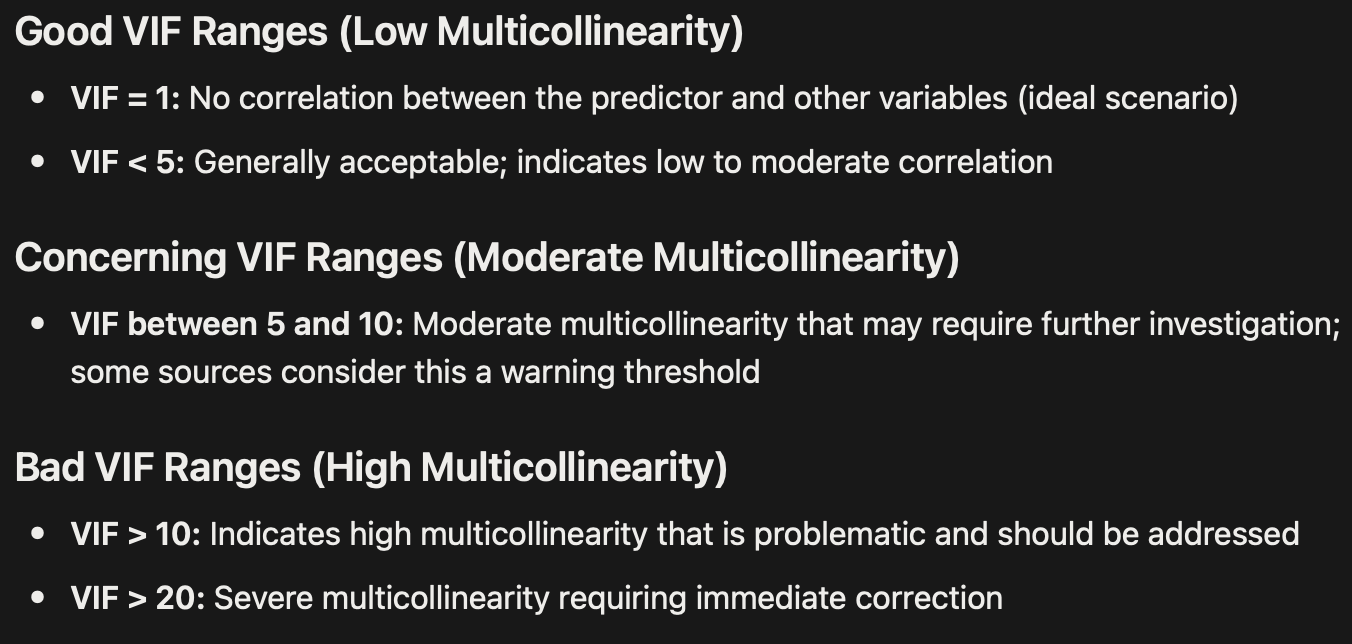

At-Bats and Hits are both very high variance inflation factors, which is also a strong indicator of multicollinearity. Now we can check condition index as a final check.

### 3.) Condition Index

In [64]:
# Normalize the independent variables first

normalized_features = (X - X.mean()) / X.std()

cov_matrix = np.cov(normalized_features.T)

eigenvalues, _ = np.linalg.eig(cov_matrix)

condition_indices = np.sqrt(eigenvalues.max() / eigenvalues)

ci_data = pd.DataFrame({
    'Condition Index': condition_indices
})

ci_data

,Condition Index
0,1.000000
1,3.052749
2,1.405440
3,1.347116


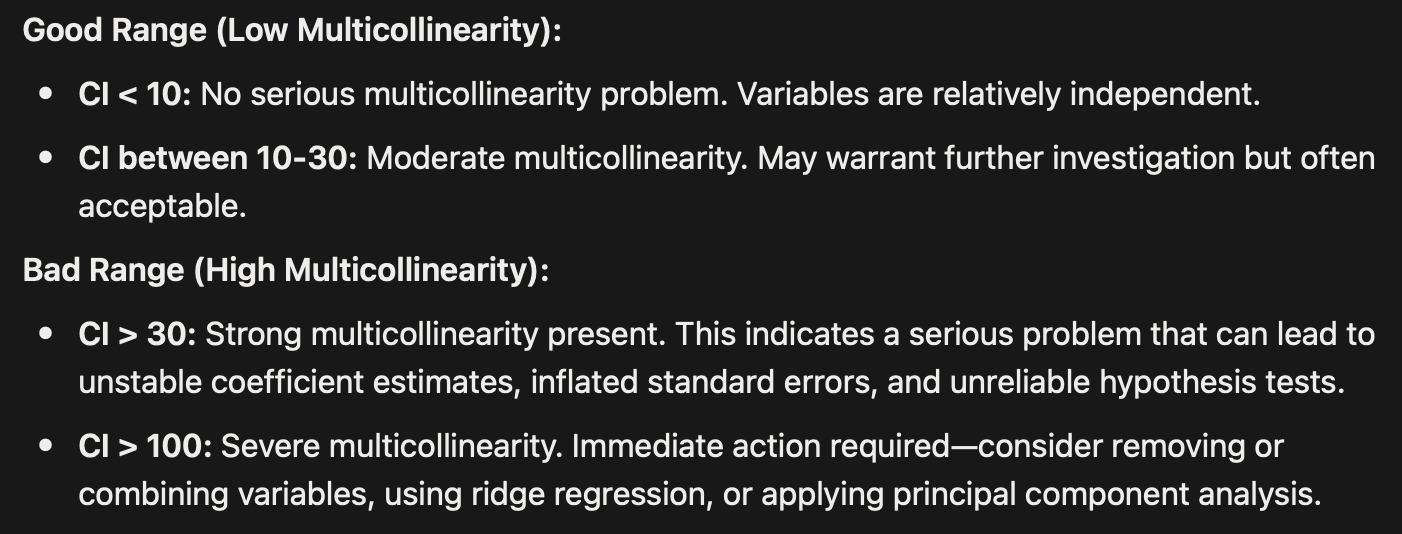

The Condition indices actually came out to pretty good scores, so this doesn't really show any multicollinearity. But, since the correlation matrix and the variance inflation factors did, we can still assume that there is multicollinearity in our data. We will now treat this by removing one of the features that is driving the multicollinearity.

# Fix Multicollinearity in Data

#### 1.) Correlation Matrix for feature reduced dataset

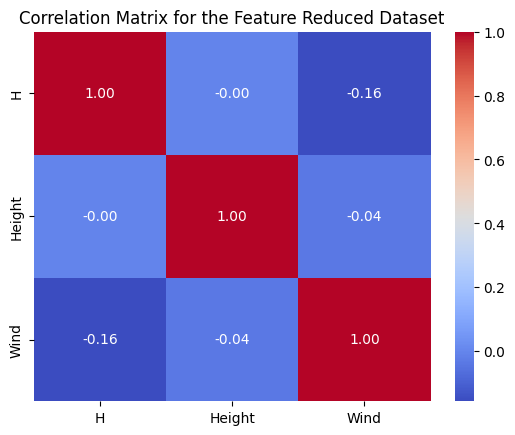

In [65]:
# Drop one of the features (AB)
X_reduced = data[['H', 'Height', 'Wind']]

# Check the new correlation matrix with the reduced features
corr_matrix_2 = X_reduced.corr()
sns.heatmap(corr_matrix_2, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'Correlation Matrix for the Feature Reduced Dataset')
plt.show()

We can see that there are no longer any highly correlated features in our independent variable dataset. We can check the VIF and CI scores now too.

### 2.) Variance Inflation Factors for feature reduced dataset

In [68]:
vif_data_2 = pd.DataFrame()

vif_data_2['Feature'] = X_reduced.columns

vif_data_2['VIF'] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]

vif_data_2

,Feature,VIF
0,H,12.085849
1,Height,12.078595
2,Wind,1.020103


The VIF scores are much better than before, even though still above 10. Ideally, they are below 10 but this will suffice compared to the VIF scores we had before. Since the Condition Indices of the original dataset were good, there is no point in running it again. 

# Run the new Linear Regression model to predict RBIs, with the fixed dataset

In [88]:
# Use just the reduced features set for the new model
lr_reduced = LinearRegression()
lr_reduced.fit(X_train[['H', 'Height', 'Wind']], y_train)
y_pred_reduced = lr_reduced.predict(X_test[['H', 'Height', 'Wind']])

# Print the MSE, RMSE, R2 Score, and MAE of the reduced X dataset model
print('Reduced Linear Regression Results')
print(f'Mean                                   : {y_pred_reduced.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred_reduced)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred_reduced)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred_reduced))/(y_pred_reduced.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred_reduced)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred_reduced)}')

# Show the values of the baseline model to compare:
print('\nBaseline Linear Regression Results')
print(f'Mean                                   : {y_pred.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred))/(y_pred.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred)}')


Reduced Linear Regression Results
Mean                                   : 73.80619538873131
Mean Squared Error                     : 73.2351456799601
Root Mean Squared Error                : 8.557753541669689
Root Mean Squared Error as a % of Mean : 0.11594898634994917
R2 Score                               : 0.8831677211410247
Mean Absolute Error                    : 6.966310448118446

Baseline Linear Regression Results
Mean                                   : 73.80596188819412
Mean Squared Error                     : 73.94824562410572
Root Mean Squared Error                : 8.599316578897751
Root Mean Squared Error as a % of Mean : 0.11651249247214653
R2 Score                               : 0.8820301103565412
Mean Absolute Error                    : 6.998828484794293


The performance results are slightly better, although not by very much. Next, I will conduct Principal Component Analysis (PCA) to select the features to use in the Linear Regression Model

# PCA Treated Linear Regression Model

In [87]:
# Use 3 components because we originally have 4, but we know we need to drop one due to multicollinearity
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)

# Print the MSE, RMSE, R2 Score, and MAE of the PCA X dataset model
print('PCA Linear Regression Results')
print(f'Mean                                   : {y_pred_pca.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred_pca)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred_pca)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred_pca))/(y_pred_pca.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred_pca)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred_pca)}')

# Show the values of the reduced X dataset model to compare:
print('\nReduced Linear Regression Results')
print(f'Mean                                   : {y_pred_reduced.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred_reduced)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred_reduced)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred_reduced))/(y_pred_reduced.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred_reduced)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred_reduced)}')

# Show the values of the baseline model to compare:
print('\nBaseline Linear Regression Results')
print(f'Mean                                   : {y_pred.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred))/(y_pred.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred)}')


PCA Linear Regression Results
Mean                                   : 73.02404357885388
Mean Squared Error                     : 135.992104190377
Root Mean Squared Error                : 11.661565254732189
Root Mean Squared Error as a % of Mean : 0.15969487148626094
R2 Score                               : 0.7830513301793488
Mean Absolute Error                    : 9.821235885395794

Reduced Linear Regression Results
Mean                                   : 73.80619538873131
Mean Squared Error                     : 73.2351456799601
Root Mean Squared Error                : 8.557753541669689
Root Mean Squared Error as a % of Mean : 0.11594898634994917
R2 Score                               : 0.8831677211410247
Mean Absolute Error                    : 6.966310448118446

Baseline Linear Regression Results
Mean                                   : 73.80596188819412
Mean Squared Error                     : 73.94824562410572
Root Mean Squared Error                : 8.599316578897751
Root Mean

As we can see the PCA X data model did not perform better than the X reduced data model or the baseline model. As of now, I would want to stick with the X reduced data model. Lastly, I will check the Ridge treated model.

# Ridge Regression Model
 - Using all of the original X features

In [86]:
ridge = Ridge()
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

# Show the values of the Ridge Regression model to compare:
print('Ridge Regression Results')
print(f'Mean                                   : {y_pred_ridge.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred_ridge)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred_ridge)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred_ridge))/(y_pred_ridge.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred_ridge)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred_ridge)}')

# Show the values of the PCA treated Linear Regression model to compare:
print('\nPCA Linear Regression Results')
print(f'Mean                                   : {y_pred_pca.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred_pca)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred_pca)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred_pca))/(y_pred_pca.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred_pca)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred_pca)}')

# Show the values of the reduced X dataset model to compare:
print('\nReduced Linear Regression Results')
print(f'Mean                                   : {y_pred_reduced.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred_reduced)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred_reduced)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred_reduced))/(y_pred_reduced.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred_reduced)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred_reduced)}')

# Show the values of the baseline model to compare:
print('\nBaseline Linear Regression Results')
print(f'Mean                                   : {y_pred.mean()}')
print(f'Mean Squared Error                     : {mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error                : {root_mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error as a % of Mean : {(root_mean_squared_error(y_test, y_pred))/(y_pred.mean())}')
print(f'R2 Score                               : {r2_score(y_test, y_pred)}')
print(f'Mean Absolute Error                    : {mean_absolute_error(y_test, y_pred)}')

Ridge Regression Results
Mean                                   : 73.7991275266506
Mean Squared Error                     : 73.88990624164475
Root Mean Squared Error                : 8.595923815486312
Root Mean Squared Error as a % of Mean : 0.116477309469304
R2 Score                               : 0.8821231793732934
Mean Absolute Error                    : 7.001793782854631

PCA Linear Regression Results
Mean                                   : 73.02404357885388
Mean Squared Error                     : 135.992104190377
Root Mean Squared Error                : 11.661565254732189
Root Mean Squared Error as a % of Mean : 0.15969487148626094
R2 Score                               : 0.7830513301793488
Mean Absolute Error                    : 9.821235885395794

Reduced Linear Regression Results
Mean                                   : 73.80619538873131
Mean Squared Error                     : 73.2351456799601
Root Mean Squared Error                : 8.557753541669689
Root Mean Squared Erro

After looking at the performance of all the regression models we conducted, we can see that the best performing model was the Linear Regression model with reduced X variables from investigating multicollinearity.